<a href="https://colab.research.google.com/github/Dansouza-web/Caso-de-Estudo-De-Uma-Empresa-de-Biclietas-do-Curso-De-An-lise-de-Dados-do-Google/blob/main/Limpeza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving 202602-divvy-tripdata.csv to 202602-divvy-tripdata.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import numpy as np
df = pd.read_csv('202602-divvy-tripdata.csv')
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4194C9D5CAFDBE7C,electric_bike,2026-02-08 17:08:34.392,2026-02-08 17:13:57.661,NaN,NaN,NaN,NaN,41.95,-87.65,41.96,-87.65,member
1,790A93E87E5EE83C,electric_bike,2026-02-08 14:44:11.880,2026-02-08 14:48:14.329,NaN,NaN,NaN,NaN,41.89,-87.62,41.89,-87.62,member
2,21ABD91CD9FB7D13,electric_bike,2026-02-08 14:38:03.488,2026-02-08 14:41:19.976,NaN,NaN,NaN,NaN,41.94,-87.67,41.94,-87.66,member
3,8D97FE9075293A3B,electric_bike,2026-02-07 19:20:35.501,2026-02-07 19:20:58.619,NaN,NaN,NaN,NaN,41.90,-87.63,41.90,-87.63,member
4,03A65D965372A020,electric_bike,2026-02-07 20:47:02.949,2026-02-07 20:47:18.752,NaN,NaN,NaN,NaN,41.89,-87.62,41.89,-87.62,member


In [5]:
df = df.dropna()

In [6]:
df= df.drop_duplicates()

In [7]:
df['started_at']=pd.to_datetime(df['started_at'])
df['ended_at']=pd.to_datetime(df['ended_at'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147622 entries, 249 to 201449
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             147622 non-null  object        
 1   rideable_type       147622 non-null  object        
 2   started_at          147622 non-null  datetime64[ns]
 3   ended_at            147622 non-null  datetime64[ns]
 4   start_station_name  147622 non-null  object        
 5   start_station_id    147622 non-null  object        
 6   end_station_name    147622 non-null  object        
 7   end_station_id      147622 non-null  object        
 8   start_lat           147622 non-null  float64       
 9   start_lng           147622 non-null  float64       
 10  end_lat             147622 non-null  float64       
 11  end_lng             147622 non-null  float64       
 12  member_casual       147622 non-null  object        
dtypes: datetime64[ns](2), float64(4)

In [8]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# criando uma coluna para o tempo de viagem
df['ride_lenght'] = df['ended_at'] - df['started_at']
# e convertendo para horas pra ter uma melhor visualização na hora de análisar os dados
df['duration_travel_hours'] = df['ride_lenght'].dt.total_seconds() / 60
df.duration_travel_hours.round()
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_lenght,duration_travel_hours
249,E79ED7DA83F9D6E7,electric_bike,2026-02-08 19:42:34.755,2026-02-08 19:51:24.780,Wood St & Chicago Ave,CHI01183,California Ave & Division St,CHI00340,41.895634,-87.672069,41.903029,-87.697474,member,0 days 00:08:50.025000,8.833750
614,A5EFD2FCDD150849,classic_bike,2026-02-13 18:32:05.231,2026-02-13 18:45:35.480,Morgan Ave & 14th Pl,CHI00261,Morgan Ave & 14th Pl,CHI00261,41.862378,-87.651062,41.862378,-87.651062,member,0 days 00:13:30.249000,13.504150
615,C4FA084B38884EDA,classic_bike,2026-02-13 18:00:48.557,2026-02-13 18:28:24.480,Morgan Ave & 14th Pl,CHI00261,Morgan Ave & 14th Pl,CHI00261,41.862378,-87.651062,41.862378,-87.651062,member,0 days 00:27:35.923000,27.598717
1688,A5EB49AAE4CBEEB1,classic_bike,2026-02-19 18:03:08.215,2026-02-19 18:13:10.893,Wood St & Chicago Ave,CHI01183,Wood St & Chicago Ave,CHI01183,41.895634,-87.672069,41.895634,-87.672069,member,0 days 00:10:02.678000,10.044633
1726,1031C025953A241C,classic_bike,2026-02-12 17:44:26.402,2026-02-12 17:55:52.933,Wood St & Chicago Ave,CHI01183,Wood St & Chicago Ave,CHI01183,41.895634,-87.672069,41.895634,-87.672069,member,0 days 00:11:26.531000,11.442183


In [9]:
#mudando os nomes das colunas para uma análise mais facil
df.columns =df.columns.str.lower()

In [10]:
#adicionando colunas úteis para a analíse
#dia da semana
df['day_of_week']=df['started_at'].dt.day_name()
#hora
df['hour']=df['started_at'].dt.hour

In [ ]:
#AQUI EU COMEÇO A ANÁLISE

In [11]:
#começo vendo o total de viagens realizadas por ano
total_de_viagens_2026 = len(df['started_at'])
print(f"Total de viagens em 2026 : {total_de_viagens_2026}")

Total de viagens em 2026 : 147622


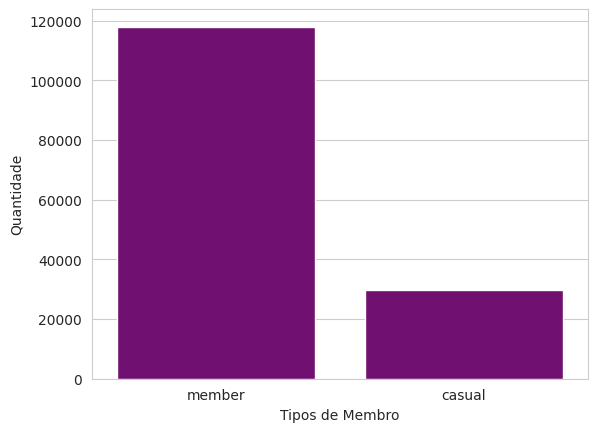

In [12]:
df['member_casual'].value_counts()
sns.countplot(data=df, x='member_casual',color='purple')
plt.xlabel('Tipos de Membro')
plt.ylabel('Quantidade')
plt.show()

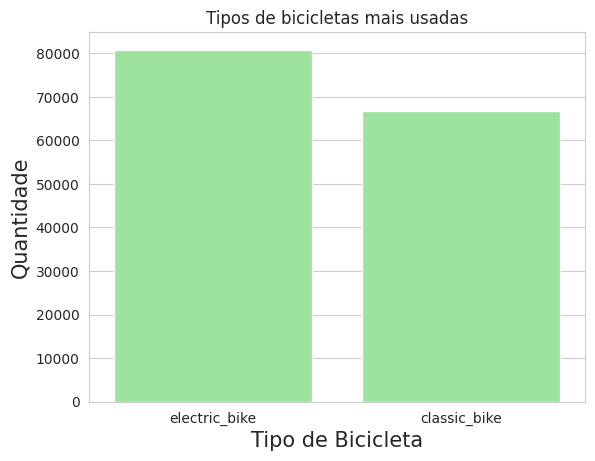

In [13]:
#procuro pelo tipo de bike que mais é citado na base de dados
df_tipos_de_bicleta_mais_usadas=df['rideable_type'].value_counts()
sns.axes_style('whitegrid'),sns.barplot(x= df_tipos_de_bicleta_mais_usadas.index, y= df_tipos_de_bicleta_mais_usadas, color='lightgreen')
plt.title('Tipos de bicicletas mais usadas')
plt.xlabel('Tipo de Bicicleta',fontsize=15)
plt.ylabel('Quantidade',fontsize=15)
plt.show()

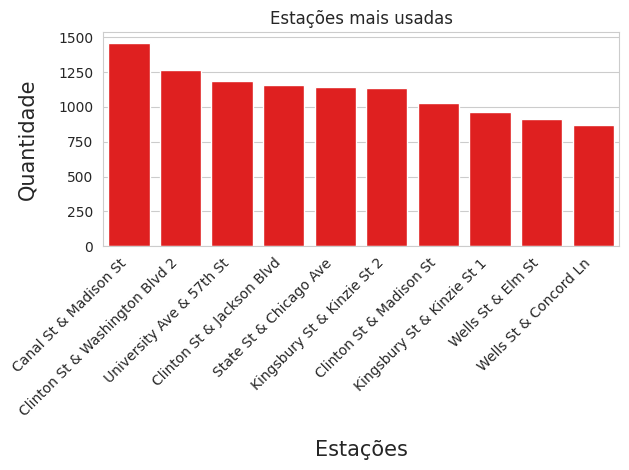

In [14]:
#vendo quais são as estações mais usadas
df_estações_mais_usadas = df['start_station_name'].value_counts().head(10)
sns.barplot(x=df_estações_mais_usadas.index, y=df_estações_mais_usadas.values,color='red')
plt.title('Estações mais usadas')
plt.xticks(size= 10,rotation=45, ha='right')
plt.xlabel('Estações',fontsize=15, labelpad=15)
plt.ylabel('Quantidade',fontsize=15,labelpad=15)
plt.tight_layout()
plt.show()

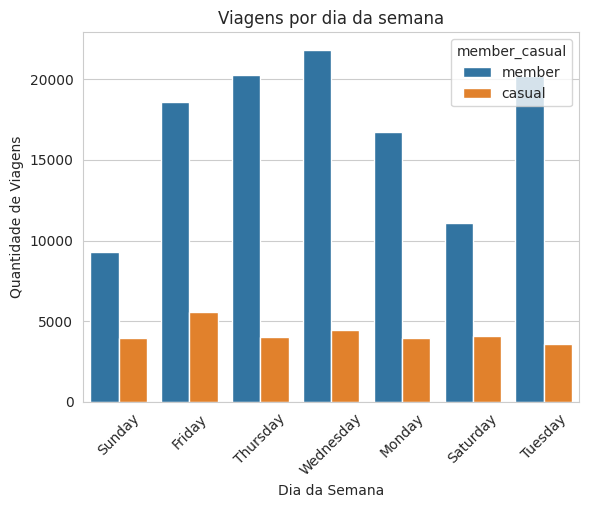

In [16]:
# vendo em que dias há mais viagens por tipos de ciclistas

sns.countplot(data=df, x='day_of_week', hue='member_casual')

plt.title("Viagens por dia da semana")
plt.xticks(rotation=45)
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Viagens')
plt.show()